In [73]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import json
import random
from itertools import combinations

# Dependency:
* DDBC
* DDBC_MSIGDB

# Loading variables

In [2]:
DISEASE = input("Disease: ")
OUTPUT_DIRECTORY = f"../output/{DISEASE}/"
NONE_OUTPUT_DIRECTORY  = f"../output/NONE/"
DGIDB_DIRECTORY = f"../../Gen_Hypergraph/output/DGIDB_{DISEASE}/"
MSIGDB_DIRECTORY = f"../../Gen_Hypergraph/output/MSIGDB_FULL/"

In [58]:
with open(f"{DGIDB_DIRECTORY}/gene_to_index.json", "rb") as f:
    dgidb_gene_to_index = json.load(f)
with open(f"{MSIGDB_DIRECTORY}/gene_to_index.json", "rb") as f:
    msigdb_gene_to_index = json.load(f)
with open(f"{OUTPUT_DIRECTORY}/gene_to_index_distinct.json", "rb") as f:
    gene_to_index_distinct = json.load(f)
with open(f"{OUTPUT_DIRECTORY}/dgidb_to_msigdb_indices_dict.json", "rb") as f:
    dgidb_to_msigdb_indices_dict = json.load(f)
# with open(f"{OUTPUT_DIRECTORY}/dgidb_ori_idx.pkl", "rb") as f:
#     dgidb_ori_idx = pickle.load(f)
# with open(f"{OUTPUT_DIRECTORY}/dgidb_agg_idx.pkl", "rb") as f:
#     dgidb_agg_idx = pickle.load(f)

In [ ]:
num_distinct_genes = len(gene_to_index_distinct)
num_genes_msigdb = len(msigdb_gene_to_index)
num_additional_rows = num_distinct_genes - num_genes_msigdb

In [45]:
print(num_distinct_genes,num_genes_msigdb,num_additional_rows)

21991 21981 10


In [ ]:
# ## Sanity Check
# index_to_gene_distinct = {v: k for k, v in gene_to_index_distinct.items()}
# dgidb_index_to_gene = {v: k for k, v in dgidb_gene_to_index.items()}
# msigdb_index_to_gene = {v: k for k, v in msigdb_gene_to_index.items()}

# for i in range(len(dgidb_agg_idx)):
#     gene_name = index_to_gene_distinct[dgidb_agg_idx[i]]
#     p = dgidb_gene_to_index.get(gene_name, None)
#     assert p is not None

# for i in range(len(dgidb_ori_idx)):
#     gene_name = msigdb_index_to_gene[dgidb_ori_idx[i]]
#     p = dgidb_gene_to_index.get(gene_name, None)
#     assert p is not None

In [8]:
# load ddm
ddm_both = np.load(f"{OUTPUT_DIRECTORY}/ddm_[2, 4, 6, 8].npy")

In [40]:
ddm_both_cropped = ddm_both[num_additional_rows:, num_additional_rows:]

In [49]:
# load npy arrays for NONE
ddm_msigdb = np.load(f"{NONE_OUTPUT_DIRECTORY}/ddm_[2, 4, 6, 8].npy")

In [79]:
indices = [x for x in list(dgidb_to_msigdb_indices_dict.values()) if x is not None]

# New Fig 4

In [ ]:
num_samples = int(1e6)

In [ ]:
# Random Sample
distance_single = []
distance_both = []
for _ in range(num_samples):
    i, j = random.sample(range(num_genes_msigdb), 2)
    d_single = ddm_msigdb[i,j]
    d_both = ddm_both_cropped[i,j]
    distance_single.append(d_single)
    distance_both.append(d_both)

In [81]:
# DGIDB Pairwise Only
distance_single = []
distance_both = []
for i,j in combinations(indices,2):
    d_single = ddm_msigdb[i,j]
    d_both = ddm_both_cropped[i,j]
    distance_single.append(d_single)
    distance_both.append(d_both)

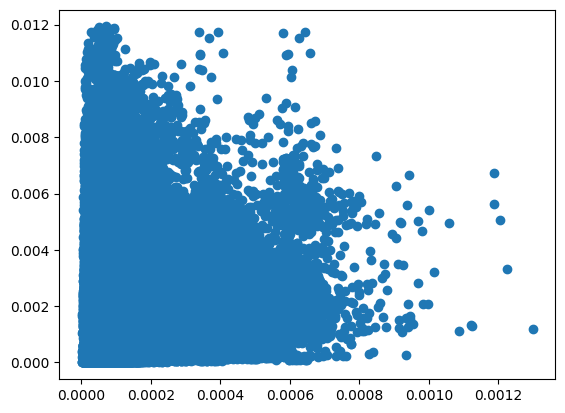

In [82]:
plt.scatter(distance_single,distance_both)

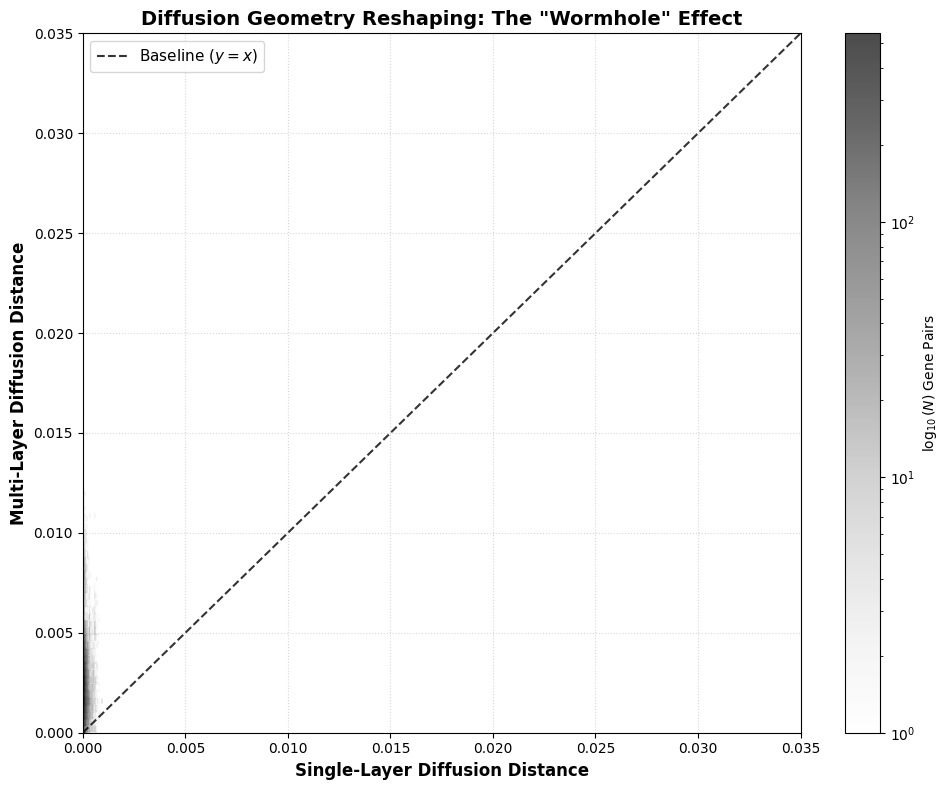

In [88]:
fig, ax = plt.subplots(figsize=(10, 8))

# --- THE BACKGROUND (Choose Hexbin OR KDE) ---

# Choice 1: Hexbin (Best if you have millions of points; very fast)
# 'bins=log' is crucial here so the few dense areas don't wash out the rest
hb = ax.hexbin(distance_single, distance_both, gridsize=60, cmap='Greys',
               mincnt=1, bins='log', alpha=0.7)
cb = fig.colorbar(hb, ax=ax, label='$\log_{10}(N)$ Gene Pairs')

# Choice 2: Seaborn KDE (Uncomment below if you prefer smooth topographic lines)
# Note: KDE can be slow to compute if you feed it millions of rows.
# sns.kdeplot(x=single_layer_bg, y=multi_layer_bg, cmap="Greys", fill=True,
#             thresh=0.05, levels=10, ax=ax, alpha=0.7)

# --- THE REFERENCE LINE ---
# Draw the y=x line to show where points *would* be if nothing changed
ax.plot([0, 0.035], [0, 0.035], color='black', linestyle='--', linewidth=1.5,
        alpha=0.8, zorder=3, label='Baseline ($y=x$)')

# ==========================================
# 3. FORMATTING FOR PUBLICATION
# ==========================================
ax.set_xlabel('Single-Layer Diffusion Distance', fontsize=12, fontweight='bold')
ax.set_ylabel('Multi-Layer Diffusion Distance', fontsize=12, fontweight='bold')
ax.set_title('Diffusion Geometry Reshaping: The "Wormhole" Effect', fontsize=14, fontweight='bold')

# Clean up axes limits based on your actual data
ax.set_xlim(0, 0.035)
ax.set_ylim(0, 0.035)

ax.legend(fontsize=11, loc='upper left')
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# diffusion distance comparison

In [13]:
# average of each row
ddm_multilayer_avg    = np.asarray(np.mean(ddm_both, axis=1)).ravel()
ddm_singlelayer_avg = np.asarray(np.mean(ddm_msigdb, axis=1)).ravel()
ddm_multilayer_avg_DGIDB    = np.asarray(np.mean(ddm_both[:,dgidb_agg_idx], axis=1)).ravel()
ddm_singlelayer_avg_DGIDB = np.asarray(np.mean(ddm_msigdb[:,dgidb_ori_idx], axis=1)).ravel()

In [28]:
ddm_singlelayer_avg_DGIDB

array([8.90186784e-05, 7.70449915e-05, 9.43964624e-05, ...,
       3.23059561e-04, 1.10624664e-04, 1.16423063e-04], dtype=float32)

In [14]:
# align the two arrays by length
print(len(ddm_multilayer_avg), len(ddm_singlelayer_avg))

21991 21981


In [15]:
average_diff_dist_DGIDB_MSIGDB_singlelayer = np.asarray([ddm_singlelayer_avg[u] for u in dgidb_ori_idx])
average_diff_dist_DGIDB_DGIDB_singlelayer = np.asarray([ddm_singlelayer_avg_DGIDB[u] for u in dgidb_agg_idx])
average_diff_dist_MSIGDB_MSIGDB_singlelayer = np.asarray(ddm_singlelayer_avg)

In [16]:
average_diff_dist_DGIDB_MSIGDB_multilayer = np.asarray([ddm_multilayer_avg[u] for u in dgidb_agg_idx])
average_diff_dist_DGIDB_DGIDB_multilayer = np.asarray([ddm_multilayer_avg_DGIDB[u] for u in dgidb_agg_idx])
average_diff_dist_MSIGDB_MSIGDB_multilayer = np.asarray(ddm_multilayer_avg[num_add_rows:])

In [17]:
print(len(average_diff_dist_DGIDB_MSIGDB_singlelayer))
print(len(average_diff_dist_DGIDB_MSIGDB_multilayer))
print(len(average_diff_dist_DGIDB_DGIDB_singlelayer))
print(len(average_diff_dist_DGIDB_DGIDB_multilayer))

349
349
349
349


In [18]:
# setting universal font sizes
font_size = 25
tick_font_size = 16
plt.rcParams.update({
    "font.size": font_size,          # base font size
    "axes.titlesize": font_size,
    "axes.labelsize": font_size,
    "xtick.labelsize": tick_font_size,
    "ytick.labelsize": tick_font_size,
    "legend.fontsize": font_size,
    "figure.titlesize": font_size,
    "legend.loc": 'best'
})


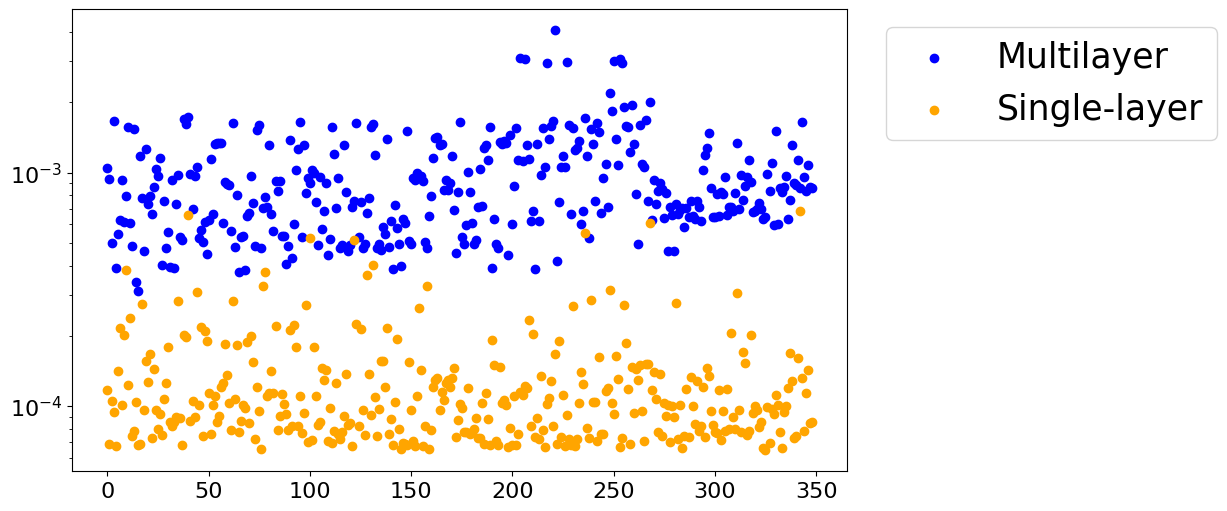

In [19]:
# DGIDB rows comparing to all genes
xaxis = range(len(average_diff_dist_DGIDB_MSIGDB_singlelayer))
plt.figure(figsize=(10, 6))
plt.scatter(xaxis, average_diff_dist_DGIDB_MSIGDB_multilayer, label='Multilayer', color='blue')
plt.scatter(xaxis, average_diff_dist_DGIDB_MSIGDB_singlelayer, label='Single-layer', color='orange')
plt.yscale('log')
# legend placed outside of plot
plt.legend(bbox_to_anchor=(1.5, 1), loc='upper right')
plt.savefig(f"../../Graphs/{DISEASE}/diff_dist_DGIDB_MSIGDB_comp.png", bbox_inches='tight')

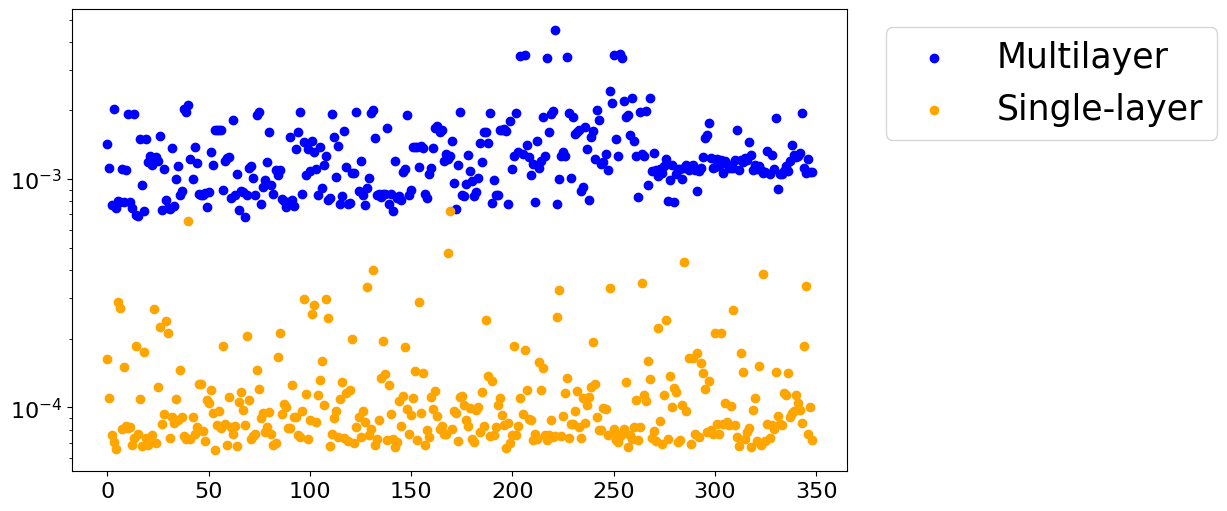

In [22]:
# DGIDB rows comparing to DGIDB genes
xaxis = range(len(average_diff_dist_DGIDB_DGIDB_singlelayer))
plt.figure(figsize=(10, 6))
plt.scatter(xaxis, average_diff_dist_DGIDB_DGIDB_multilayer, label='Multilayer', color='blue')
plt.scatter(xaxis, average_diff_dist_DGIDB_DGIDB_singlelayer, label='Single-layer', color='orange')
plt.yscale('log')
# legend placed outside of plot
plt.legend(bbox_to_anchor=(1.5, 1), loc='upper right')
plt.savefig(f"../../Graphs/{DISEASE}/diff_dist_DGIDB_DGIDB_comp.png", bbox_inches='tight')

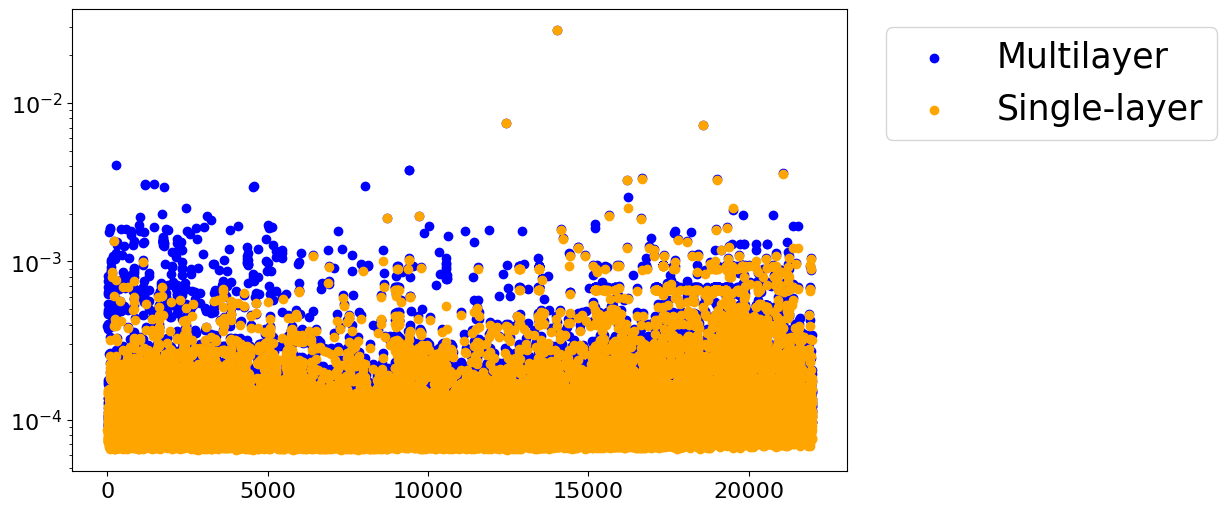

In [23]:
# all rows comparing to all genes
xaxis = range(len(average_diff_dist_MSIGDB_MSIGDB_singlelayer))
plt.figure(figsize=(10, 6))
plt.scatter(xaxis, average_diff_dist_MSIGDB_MSIGDB_multilayer, label='Multilayer', color='blue')
plt.scatter(xaxis, average_diff_dist_MSIGDB_MSIGDB_singlelayer, label='Single-layer', color='orange')
plt.yscale('log')
# legend placed outside of plot
plt.legend(bbox_to_anchor=(1.5, 1), loc='upper right')
plt.savefig(f"../../Graphs/{DISEASE}/diff_dist_MSIGDB_MSIGDB_comp.png", bbox_inches='tight')

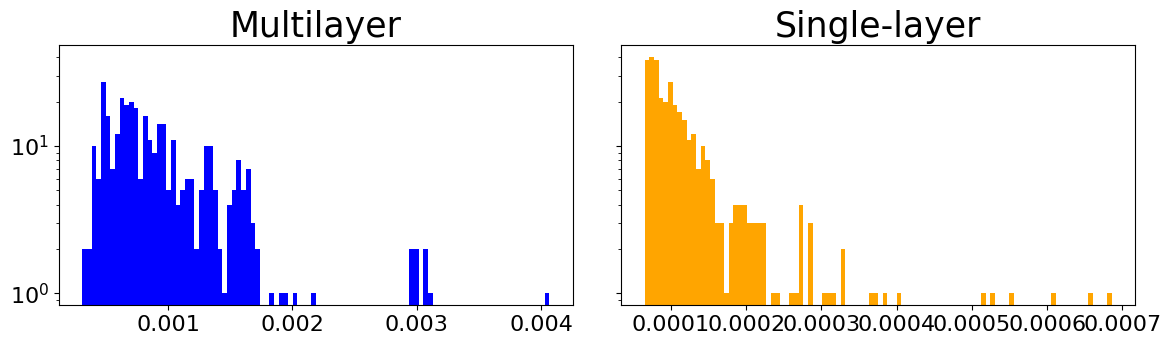

In [33]:
# DGIDB rows comparing to all genes - Histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax in axes:
    ax.set_yscale("log")

axes[0].hist(average_diff_dist_DGIDB_MSIGDB_multilayer, bins=100, color='blue')
axes[0].set_title("Multilayer")

axes[1].hist(average_diff_dist_DGIDB_MSIGDB_singlelayer, bins=100, color='orange')
axes[1].set_title("Single-layer")

plt.tight_layout()
plt.savefig(f"../../Graphs/{DISEASE}/diff_dist_DGIDB_MSIGDB_histogram.png", bbox_inches='tight')
plt.show()



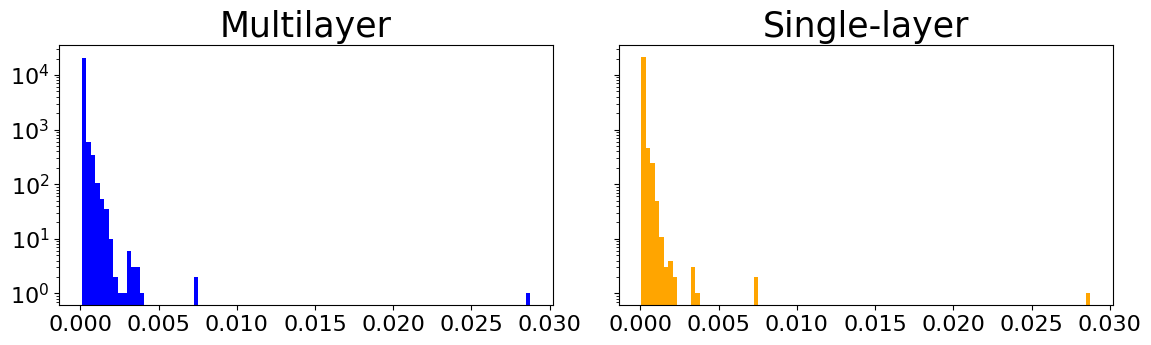

In [34]:
# DGIDB rows comparing to all genes - Histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax in axes:
    ax.set_yscale("log")

axes[0].hist(average_diff_dist_MSIGDB_MSIGDB_multilayer, bins=100, color='blue')
axes[0].set_title("Multilayer")

axes[1].hist(average_diff_dist_MSIGDB_MSIGDB_singlelayer, bins=100, color='orange')
axes[1].set_title("Single-layer")

plt.tight_layout()
plt.savefig(f"../../Graphs/{DISEASE}/diff_dist_MSIGDB_MSIGDB_histogram.png", bbox_inches='tight')
plt.show()



In [30]:
diff_dist_stat = {
    "DGIDB_MSIGDB_singlelayer": {"mean": float(average_diff_dist_DGIDB_MSIGDB_singlelayer.mean()), "var": float(average_diff_dist_DGIDB_MSIGDB_singlelayer.var())},
    "DGIDB_MSIGDB_multilayer": {"mean": float(average_diff_dist_DGIDB_MSIGDB_multilayer.mean()), "var": float(average_diff_dist_DGIDB_MSIGDB_multilayer.var())},
    "DGIDB_DGIDB_singlelayer": {"mean": float(average_diff_dist_DGIDB_DGIDB_singlelayer.mean()), "var": float(average_diff_dist_DGIDB_DGIDB_singlelayer.var())},
    "DGIDB_DGIDB_multilayer": {"mean": float(average_diff_dist_DGIDB_DGIDB_multilayer.mean()), "var": float(average_diff_dist_DGIDB_DGIDB_multilayer.var())},
    "MSIGDB_MSIGDB_singlelayer": {"mean": float(average_diff_dist_MSIGDB_MSIGDB_singlelayer.mean()), "var": float(average_diff_dist_MSIGDB_MSIGDB_singlelayer.var())},
    "MSIGDB_MSIGDB_multilayer": {"mean": float(average_diff_dist_MSIGDB_MSIGDB_multilayer.mean()), "var": float(average_diff_dist_MSIGDB_MSIGDB_multilayer.var())},
}

In [31]:
with open(f"../../Graphs/{DISEASE}/diff_dist_stat.json", "w") as f:
    json.dump(diff_dist_stat, f, indent=4)

In [47]:
# plt.figure(figsize=(10, 6))
# plt.hist([ddm_msigdb_avg,ddm_both_avg_cropped], color=['orange', 'blue'], bins = 1000)
# # plt.xlabel("Ratio of Average Diffusion Distances (Multilayer / Single-layer)", fontsize=17)
# # plt.ylabel("Count", fontsize=17)
# plt.yscale('log')
# # legend placed outside of plot
# plt.legend(['Single-layer', 'Multilayer'], bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=17)

In [48]:
# diff = ddm_both_avg_cropped / ddm_msigdb_avg

# plt.figure(figsize=(10, 6))
# plt.hist(diff, color='orange', bins = 1000)
# plt.axvline(1, color="black", linestyle="--", linewidth=2, label="baseline = 1")
# plt.xlabel("Ratio of Average Diffusion Distances (Multilayer / Single-layer)", fontsize=17)
# plt.ylabel("Count", fontsize=17)
# plt.yscale('log')
# # legend placed outside of plot